In [3]:
import pandas as pd

df = pd.read_csv("../nsl_landmarks_v2.csv")

print(df.shape)
print(df["label"].value_counts())
print(df.isnull().sum())

(48474, 65)
label
11    1500
23    1500
17    1500
12    1500
31    1500
22    1500
6     1499
16    1499
26    1499
27    1498
25    1498
29    1498
24    1497
20    1495
32    1494
10    1493
9     1489
5     1468
28    1460
18    1433
4     1414
2     1394
30    1393
14    1378
8     1333
13    1287
0     1285
21    1263
7     1228
33    1202
19    1149
1     1018
35    1005
3      897
34     889
15     519
Name: count, dtype: int64
x0         0
y0         0
z0         0
x1         0
y1         0
          ..
x20        0
y20        0
z20        0
label      0
bg_type    0
Length: 65, dtype: int64


In [4]:
import pandas as pd
import numpy as np
import joblib
import cv2
import math

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [5]:
df = pd.read_csv("../nsl_landmarks.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (48474, 64)


,x0,y0,z0,x1,y1,z1,x2,y2,z2,x3,...,x18,y18,z18,x19,y19,z19,x20,y20,z20,label
0,0.0,0.0,-0.000012,-0.855550,-1.375867,0.025502,-1.042278,-2.505519,-0.093930,-1.174752,...,-1.076656,-2.526801,-0.781756,-1.054936,-2.058679,-0.645720,-0.712637,-1.844291,-0.547171,0
1,0.0,0.0,-0.000011,-0.814246,-1.566615,0.024540,-1.031988,-2.753698,-0.119707,-1.221168,...,-1.027909,-2.735862,-0.795896,-0.991473,-2.257411,-0.670973,-0.605219,-2.028148,-0.591931,0
2,0.0,0.0,-0.000022,-0.932188,-2.272680,0.228525,-0.655216,-3.690752,0.189302,-0.380324,...,-0.046382,-4.775964,-1.037354,-0.548104,-4.230513,-0.953652,-0.488500,-3.657031,-0.768334,0
3,0.0,0.0,-0.000010,-0.624260,-0.462053,0.094638,-0.903367,-1.140657,0.151806,-1.011045,...,-0.227066,-2.229704,-0.288000,-0.389487,-1.761702,-0.230479,-0.181449,-1.407042,-0.113524,0
4,0.0,0.0,-0.000007,-0.504167,-0.460756,0.079958,-0.682428,-1.023421,0.117696,-0.588493,...,0.398373,-1.646114,-0.319378,0.199438,-1.320029,-0.197642,0.280883,-1.047338,-0.060514,0


In [6]:
print("Missing values:\n", df.isnull().sum())

print("\nClass distribution:\n", df["label"].value_counts())

total_rows = len(df)
unique_rows = len(df.drop_duplicates())

print("\nTotal rows:", total_rows)
print("Unique rows:", unique_rows)

if total_rows != unique_rows:
    print("WARNING: Duplicate samples detected!")
    

Missing values:
 x0       0
y0       0
z0       0
x1       0
y1       0
        ..
z19      0
x20      0
y20      0
z20      0
label    0
Length: 64, dtype: int64

Class distribution:
 label
11    1500
23    1500
17    1500
12    1500
31    1500
22    1500
6     1499
16    1499
26    1499
27    1498
25    1498
29    1498
24    1497
20    1495
32    1494
10    1493
9     1489
5     1468
28    1460
18    1433
4     1414
2     1394
30    1393
14    1378
8     1333
13    1287
0     1285
21    1263
7     1228
33    1202
19    1149
1     1018
35    1005
3      897
34     889
15     519
Name: count, dtype: int64

Total rows: 48474
Unique rows: 47997


In [7]:
# Remove duplicates
df_clean = df.drop_duplicates()

print("Original:", len(df))
print("After removing duplicates:", len(df_clean))

Original: 48474
After removing duplicates: 47997


In [8]:
X = df_clean.drop("label", axis=1).values
y = df_clean["label"].values

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (38397, 63)
Test shape: (9600, 63)


“MLP was selected due to its ability to model nonlinear relationships in normalized landmark space while maintaining low computational cost suitable for real-time inference.”

In [10]:
model = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    max_iter=300
)

model.fit(X_train, y_train)
print("Model training complete.")

Model training complete.


In [11]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Test Accuracy: 0.9978125

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       257
           1       1.00      0.99      0.99       203
           2       1.00      1.00      1.00       279
           3       0.99      0.97      0.98       179
           4       0.99      0.99      0.99       283
           5       1.00      1.00      1.00       294
           6       1.00      0.99      1.00       300
           7       0.99      1.00      0.99       246
           8       1.00      1.00      1.00       267
           9       1.00      1.00      1.00       298
          10       1.00      1.00      1.00       299
          11       1.00      1.00      1.00       300
          12       1.00      1.00      1.00       298
          13       1.00      1.00      1.00       257
          14       1.00      1.00      1.00       274
          15       0.99      0.99      0.99       101
          16       1.00      1.

In [12]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ====== PREDICTIONS ======
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# ====== ACCURACY ======
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

# ====== CLASSIFICATION REPORTS ======
train_report_str = classification_report(y_train, y_train_pred)
test_report_str = classification_report(y_test, y_test_pred)

train_report = classification_report(y_train, y_train_pred, output_dict=True)
test_report = classification_report(y_test, y_test_pred, output_dict=True)

# Extract macro averages (best for thesis reporting)
train_precision = train_report['macro avg']['precision']
train_recall = train_report['macro avg']['recall']
train_f1 = train_report['macro avg']['f1-score']

test_precision = test_report['macro avg']['precision']
test_recall = test_report['macro avg']['recall']
test_f1 = test_report['macro avg']['f1-score']

# ====== CREATE COMPARISON TABLE ======
comparison_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Train": [train_acc, train_precision, train_recall, train_f1],
    "Test": [test_acc, test_precision, test_recall, test_f1]
})

comparison_df = comparison_df.round(4)

print("\nTrain vs Test Performance Comparison:\n")
print(comparison_df)

# Save to CSV
comparison_df.to_csv("train_test_comparison.csv", index=False)

# ====== SAVE TEST REPORT ======
os.makedirs("../outputs", exist_ok=True)
with open("../outputs/static_test_report.txt", "w") as f:
    f.write(f"Static Model Test Accuracy: {test_acc:.4f}\n\n")
    f.write(test_report_str)

# ====== CONFUSION MATRIX (TEST) ======
cm_test = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_test, cmap="Blues", annot=True, fmt="d")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.title("Static Model - Test Confusion Matrix")
plt.tight_layout()
plt.savefig("../outputs/static_test_cm.png", dpi=100)
plt.close()

print("\n✅ Report saved: ../outputs/static_test_report.txt")
print("✅ Confusion matrix saved: ../outputs/static_test_cm.png")


Train vs Test Performance Comparison:

      Metric   Train    Test
0   Accuracy  0.9998  0.9978
1  Precision  0.9998  0.9975
2     Recall  0.9998  0.9972
3   F1-score  0.9998  0.9974

✅ Report saved: ../outputs/static_test_report.txt
✅ Confusion matrix saved: ../outputs/static_test_cm.png


In [13]:
cv_scores = cross_val_score(model, X, y, cv=5)

print("Cross-validation scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())

Cross-validation scores: [0.994375   0.983125   0.99333264 0.99229086 0.97801854]
Mean CV accuracy: 0.9882284092092926


In [14]:
joblib.dump(model, "nsl_model_static_v2.pkl")
print("Model saved as nsl_model_static.pkl")

Model saved as nsl_model_static.pkl


In [15]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

In [16]:
# Convert to numpy (just in case)
X = np.array(X)
y = np.array(y)

print("Feature shape:", X.shape)
print("Label shape:", y.shape)

Feature shape: (47997, 63)
Label shape: (47997,)


In [17]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

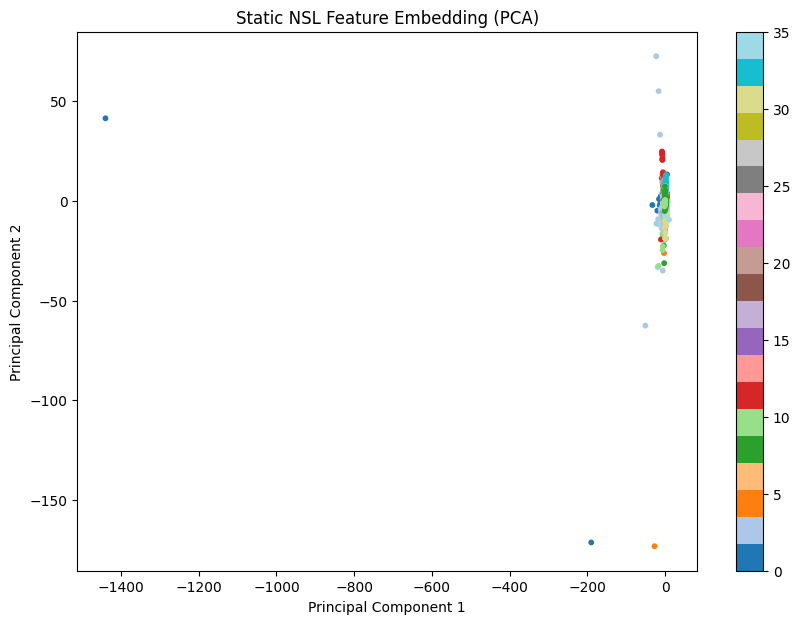

In [18]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='tab20', s=10)

plt.title("Static NSL Feature Embedding (PCA)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.colorbar(scatter)
plt.show()

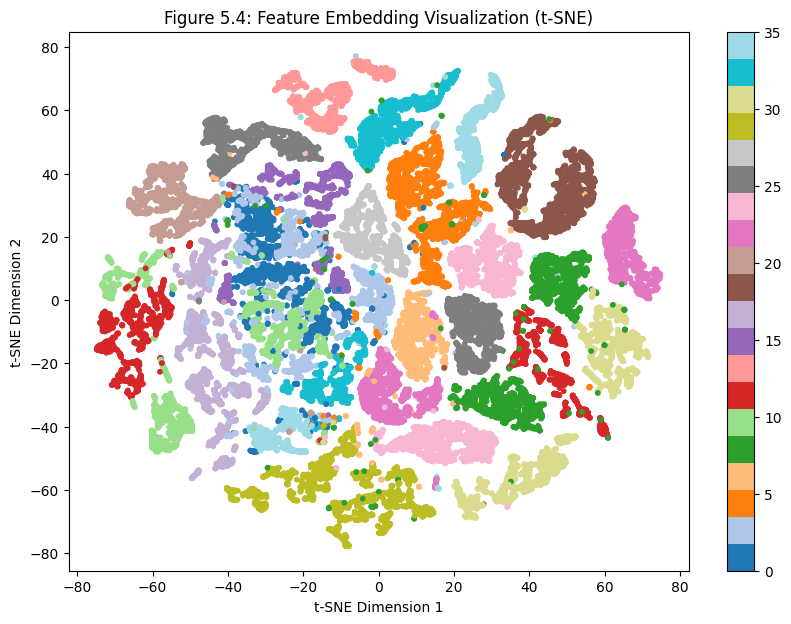

In [21]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    max_iter=1000,
    random_state=42
)

X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap='tab20', s=10)

plt.title("Figure 5.4: Feature Embedding Visualization (t-SNE)")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")

plt.colorbar(scatter)
plt.show()

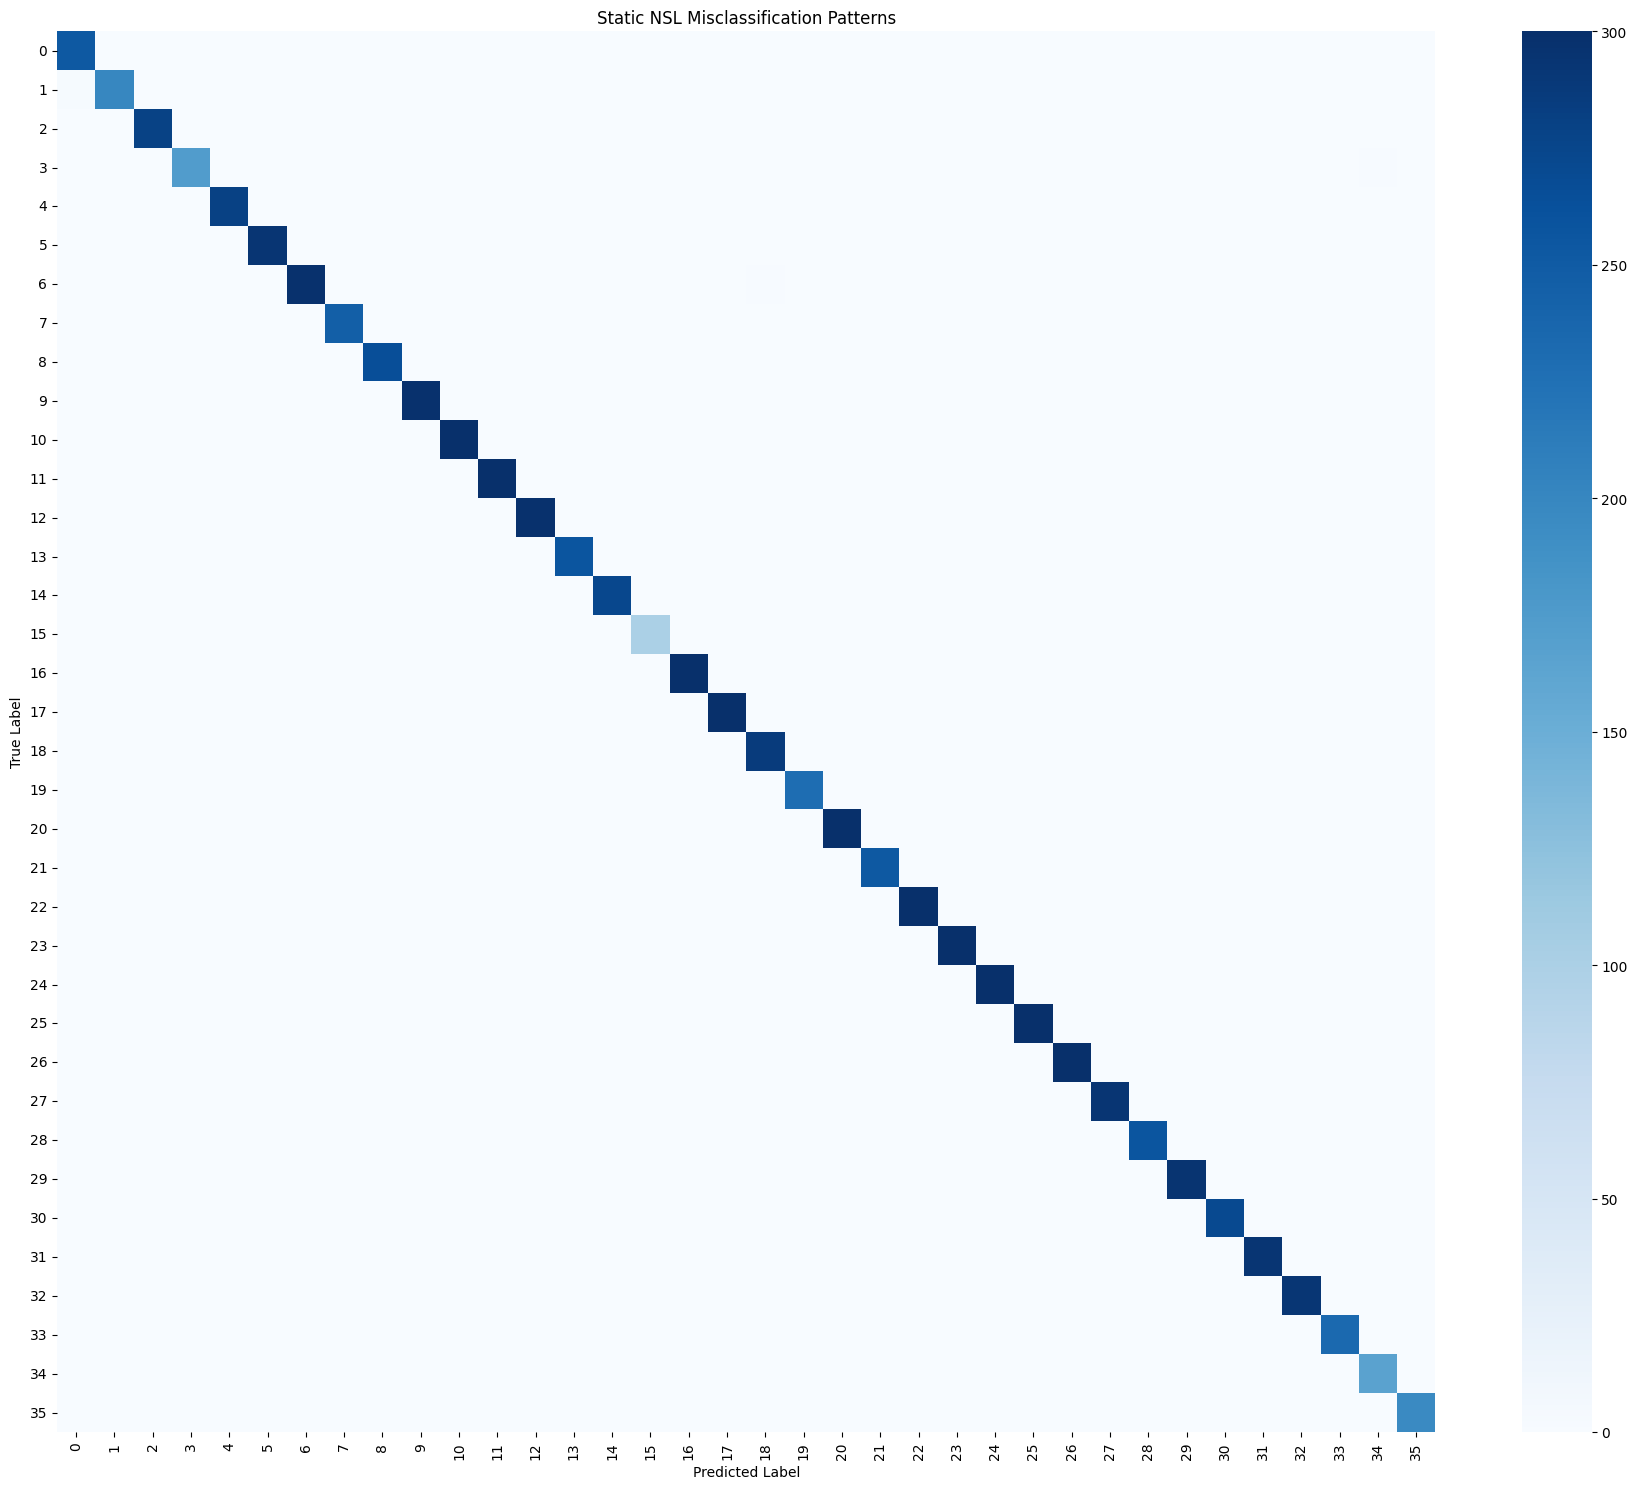

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       257
           1       1.00      0.99      0.99       203
           2       1.00      1.00      1.00       279
           3       0.99      0.97      0.98       179
           4       0.99      0.99      0.99       283
           5       1.00      1.00      1.00       294
           6       1.00      0.99      1.00       300
           7       0.99      1.00      0.99       246
           8       1.00      1.00      1.00       267
           9       1.00      1.00      1.00       298
          10       1.00      1.00      1.00       299
          11       1.00      1.00      1.00       300
          12       1.00      1.00      1.00       298
          13       1.00      1.00      1.00       257
          14       1.00      1.00      1.00       274
          15       0.99      0.99      0.99       101
          16       1.00      1.00      1.00       300
          17       1.00    

In [24]:
# ==========================================
# 5.2.4 Misclassification Pattern Analysis
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, classification_report

# Predict on test set
y_pred = model.predict(X_test)

# Use consistent class labels for plots and reports
class_labels = np.unique(y)

# ------------------------------------------
# Confusion Matrix
# ------------------------------------------

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(18, 15))

sns.heatmap(
    cm,
    annot=False,
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.title("Static NSL Misclassification Patterns")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

# ------------------------------------------
# Classification Report
# ------------------------------------------

print(classification_report(
    y_test,
    y_pred,
    target_names=[str(v) for v in class_labels]
))

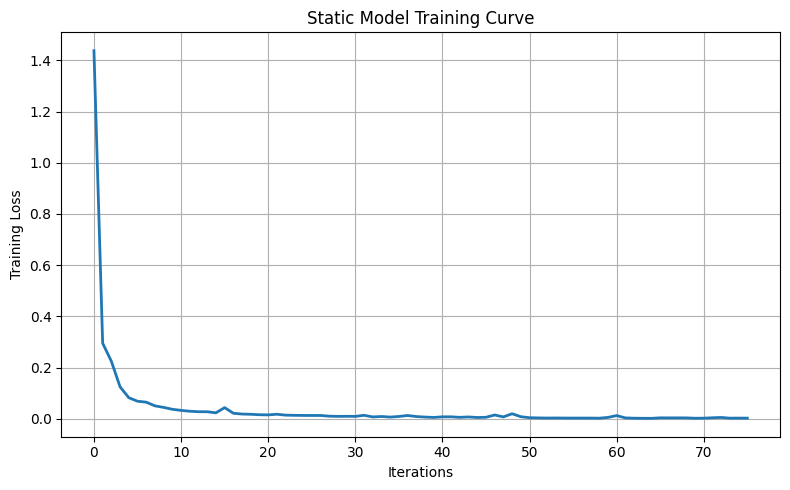

In [27]:
# ==========================================
# 5.2.5 Training Stability Visualization
# ==========================================

import matplotlib.pyplot as plt

# Loss curve from MLPClassifier
loss_values = model.loss_curve_

plt.figure(figsize=(8, 5))

plt.plot(loss_values, linewidth=2)

plt.title("Static Model Training Curve")
plt.xlabel("Iterations")
plt.ylabel("Training Loss")

plt.grid(True)

plt.tight_layout()
plt.show()

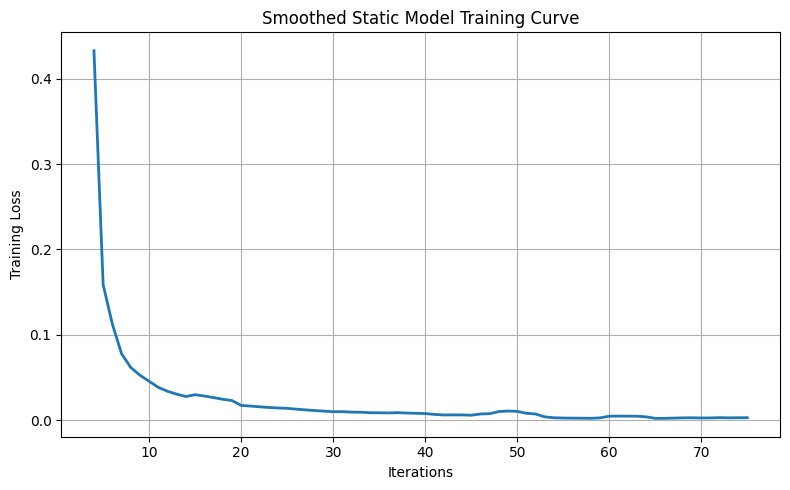

In [30]:
import pandas as pd

smooth_loss = pd.Series(loss_values).rolling(window=5).mean()

plt.figure(figsize=(8,5))

plt.plot(smooth_loss, linewidth=2)

plt.title("Smoothed Static Model Training Curve")
plt.xlabel("Iterations")
plt.ylabel("Training Loss")

plt.grid(True)

plt.tight_layout()
plt.show()